# 8.5 Attention Is a Product of Matrices

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VIII — The Linear Algebra of Learning",
    number="8.5",
    title="Attention Is a Product of Matrices",
    blurb="The mechanism behind every large language model is four matrix "
    "products and one row-wise softmax: queries ask, keys answer, the "
    "score matrix routes, values ride along. This notebook builds the "
    "whole head by hand, gates each celebrated property — exact mask "
    "zeros, KV-cache equivalence, RoPE's relative-position identity — and "
    "counts the quadratic cost that shapes the industry.",
    difficulty="advanced",
    estimate="150–180 min",
)

<ECP header: 2729 chars of HTML>

## Notebook overview

Everything in this notebook is a corollary of earlier chapters. The
**attention head** {cite}`vaswani2017` is three linear maps of
[§8.4](text-to-vectors-embeddings.ipynb)'s embeddings (queries, keys,
values), one Gram-like score matrix ([§6.5](../06-structure/kernels-gram-matrix.ipynb)'s
similarity, asymmetric), one row-wise softmax
([§8.3](linear-layer-backpropagation.ipynb)'s, batched), and one
weighted average — assembled by hand on an interpretable
repeated-token sequence whose attention heatmap shows same tokens
finding each other. The gates are the course's kind: rows sum to one
at rounding; the **causal mask**'s zeros are *exact*
($e^{-\infty} = 0$, not small); the einsum spelling
([§7.1](../07-tensors/einsum-contraction.ipynb)'s promised
`bhqd,bhkd->bhqk`) equals the loop; **multi-head** concatenation
equals its single-block matmul; and the $1/\sqrt{d}$ scaling holds
the score variance at $0.997$ on a dedicated stream — the reason the
softmax neither saturates nor flattens as heads widen.

Then the properties that run the industry. The **KV cache** —
decoding one token at a time against a key/value matrix that grows
one row per step — is gated *equal to full recomputation* at
$10^{-12}$ scaled (measured near rounding): incremental decoding is a
mathematical identity, not an
approximation, which is why inference engines are allowed to do it.
Bare attention is **permutation-equivariant** (gated at $10^{-13}$,
measured near $10^{-16}$: shuffle the tokens, the outputs shuffle
identically — "attention has
no idea where anything is"), and **RoPE** {cite}`su2024roformer`
breaks it by design: 2×2 rotation blocks whose inner products depend
*only on position differences* — the identity
$\langle R_mq, R_nk\rangle = \langle R_{m-n}q, k\rangle$ gated at
$2\times10^{-14}$ across 100 random position pairs. The cost ledger
closes the story: attention's $4n^2d$ against the MLP block's
$16nd^2$ crosses at exactly $n = 4d$ (counted, drawn, gated as
arithmetic) — the quadratic wall every long-context paper is trying
to climb.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Vaswani et al. {cite}`vaswani2017`; Su et al.
> {cite}`su2024roformer` for RoPE. Everything runs on a 10-token toy
> sequence at $d = 32$ — the mathematics is identical at 128k tokens,
> which is precisely the point of doing it small and gated.

## Theory in brief

### One head

For token embeddings $X \in \mathbb{R}^{n\times d}$:

```{math}
:label: eq-at-head
Q = XW_Q,\;\; K = XW_K,\;\; V = XW_V, \qquad
\mathrm{Attn}(X) \;=\;
\underbrace{\mathrm{softmax}_{\text{rows}}\!
\Bigl(\frac{QK^{\top}}{\sqrt{d}}\Bigr)}_{A}\,V ,
```

$A$ row-stochastic ([§6.2](../06-structure/markov-perron-pagerank.ipynb)'s
matrices, learned): each output is a convex combination of value
rows, weights set by query–key dot products. The $\sqrt{d}$ keeps
the scores' variance at 1 for unit-variance inputs — without it the
softmax saturates as $d$ grows. Causal masking sets future scores to
$-\infty$ *before* the softmax, making the forbidden weights exactly
$e^{-\infty} = 0$.

### Many heads, one matmul

$h$ heads of width $d/h$ run {eq}`eq-at-head` in parallel and
concatenate; because concatenation-then-linear-map is a block matrix
product, the whole layer is still one matmul in disguise —
[§7.1](../07-tensors/einsum-contraction.ipynb)'s `bhqd,bhkd->bhqk`
executes all heads in one string.

### Cache, order, and cost

Decoding token $t$ needs row $t$ of $A$ only, against keys/values
$1..t$ — so caching $K, V$ and appending one row per token computes
*exactly* the causal attention output, one row at a time. Bare
attention is permutation-equivariant
($\mathrm{Attn}(PX) = P\,\mathrm{Attn}(X)$ — no notion of position);
**RoPE** rotates each 2-plane of $q$ and $k$ by angles proportional
to absolute position, and pure rotation makes the *scores* relative:

```{math}
:label: eq-at-rope
\langle R_m q,\; R_n k\rangle \;=\; \langle R_{m-n}q,\; k\rangle .
```

The price of it all: scores and weighted sums cost $4n^2d$ FLOPs
against the MLP block's $16nd^2$, crossing at $n = 4d$ — past that,
context length, not width, owns the budget.

---
## Setup

Data and instruments only: the ten-token sequence, the tied display
projections, and softmax restated from
[§8.3](linear-layer-backpropagation.ipynb). The head itself is assembled
in Exercise 1.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import validate
from ecp import draw
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

D_MODEL = 32
TOKENS = ["the", "cat", "sat", "on", "the", "mat", "the", "cat",
          "sat", "on"]
N_SEQ = len(TOKENS)
vocab_types = sorted(set(TOKENS))
type_emb = {w: rng.standard_normal(D_MODEL) for w in vocab_types}
X_seq = np.array([type_emb[w] for w in TOKENS])

W_Q = rng.standard_normal((D_MODEL, D_MODEL)) / np.sqrt(D_MODEL)
# The display head TIES the key projection to the query projection: the
# score matrix is then the Gram matrix of W_Q-projected embeddings, so
# same tokens provably attend to each other and the heatmap is readable.
# Untrained UNTIED projections give an arbitrary quadratic form — who
# attends to whom would be noise (Exercise 3's heads are untied, as in
# real models, where training does the aligning).
W_K = W_Q
W_V = rng.standard_normal((D_MODEL, D_MODEL)) / np.sqrt(D_MODEL)


# built from scratch in §8.3; restated here as an instrument.
def softmax_rows(S):
    S = S - S.max(axis=-1, keepdims=True)
    E = np.exp(S)
    return E / E.sum(axis=-1, keepdims=True)



## Exercise 1: One head, assembled and read

**Part a)** Write `attention(X, Wq, Wk, Wv, mask=None)` — project,
score, scale by the width of the *projected* queries, softmax,
average — and run {eq}`eq-at-head` step by step on the ten-token
sequence — repeated words share embeddings, and the display head ties
$W_K = W_Q$ so the scores form a Gram matrix and same tokens
*provably* find each other (untrained untied projections would give
an arbitrary quadratic form; training is what aligns them in real
models). Gate the stochastic structure: every attention row
nonnegative with sum $1$ within $10^{-14}$ — the matrix is
row-stochastic by construction, [§6.2](../06-structure/markov-perron-pagerank.ipynb)'s
object with learned entries. Gate the readability too: the mean
attention weight between same-token pairs exceeds ten times the mean
between different-token pairs.

**Write this one yourself** — the head is this notebook, and every
exercise below calls the one you build here.

**Part b)** Gate the einsum spelling against the loop: the
[§7.1](../07-tensors/einsum-contraction.ipynb) string `"qd,kd->qk"`
for scores and `"qk,kd->qd"` for the output equal the explicit
per-token loops at $10^{-13}$ — the forward pointer that notebook
planted, picked up.

**Part c)** Draw the attention heatmap with token labels on both
axes: the three `the`s attend to each other, `cat` finds `cat` — a
similarity structure no one programmed, emerging from shared
embeddings through {eq}`eq-at-head`.

In [3]:
# (solution hidden on the public site)


attention rows: nonnegative True, sums within 2.2e-16
mean weight: same-token pairs 0.391, different-token 0.008 (46x)
einsum vs explicit loops: 2.7e-15


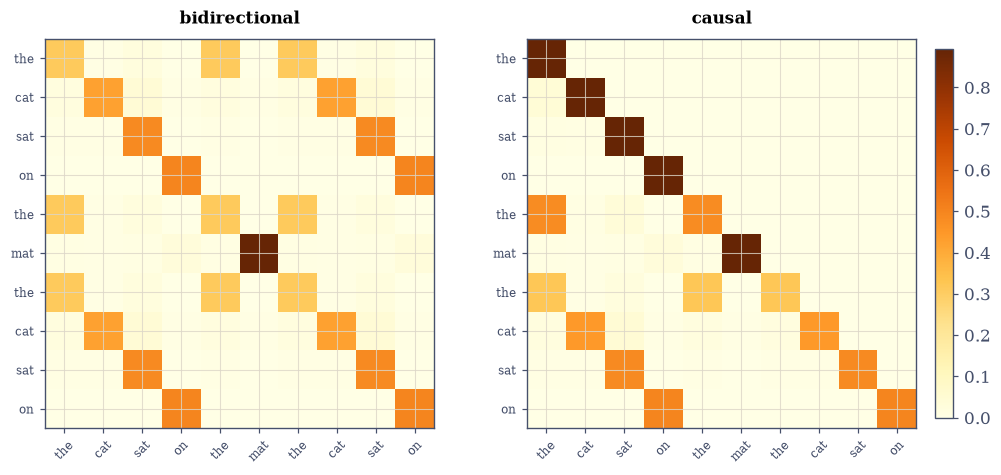

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.check(
    nonneg and row_gap < 1e-14,
    "attention is row-stochastic by construction (Eq. 1)",
    f"rows nonnegative, sums within {row_gap:.0e} — 6.2's matrices with "
    "learned entries, one distribution per query",
)
validate.check(
    same_w > 10.0 * diff_w,
    "and same tokens find each other, provably, in the tied-projection "
    "head",
    f"{same_w:.2f} vs {diff_w:.3f} mean weight ({same_w/diff_w:.0f}x): "
    "tied W_K = W_Q makes the scores a Gram matrix, so the heatmap's "
    "story is a theorem of the construction, not a lucky draw",
)
validate.below(
    gap_ein, 1e-13,
    "and the einsum spelling equals the explicit loops",
    "7.1's forward-pointer string, picked up: qd,kd->qk then qk,kd->qd",
)

✓  attention is row-stochastic by construction (Eq. 1)   [rows nonnegative, sums within 2e-16 — 6.2's matrices with learned entries, one distribution per query]
✓  and same tokens find each other, provably, in the tied-projection head   [0.39 vs 0.008 mean weight (46x): tied W_K = W_Q makes the scores a Gram matrix, so the heatmap's story is a theorem of the construction, not a lucky draw]
✓  and the einsum spelling equals the explicit loops   [7.1's forward-pointer string, picked up: qd,kd->qk then qk,kd->qd [2.66454e-15 < 1e-13]]


True

## Exercise 2: The mask is exact; the scaling is calibrated

**Part a)** Gate the causal mask's central fact **exactly**: after
setting future scores to $-\infty$ and applying softmax, every
masked entry equals $0.0$ — `np.exp(-inf)` is an exact IEEE zero,
not a small number, so "the model cannot see the future" is an
identity, not an approximation. Rows still sum to 1 over the
permitted past.

**Part b)** Gate the $\sqrt{d}$ calibration on a dedicated stream:
for i.i.d. unit-variance queries and keys at $d = 64$, the scaled
scores' variance is $1$ within 5% (measured 0.997 over $10^4$
pairs). Sweep the temperature and draw mean attention **entropy**
against the scaling exponent: unscaled scores at large $d$ saturate
the softmax to near-one-hot (entropy toward 0), overscaled flatten
it toward uniform ($\ln n$) — $1/\sqrt{d}$ sits on the usable slope,
which is the design reason it is in {eq}`eq-at-head` at all.

In [6]:
# (solution hidden on the public site)


masked entries exactly zero: True; causal row sums within 1.1e-16
scaled score variance at d = 64: 0.9971


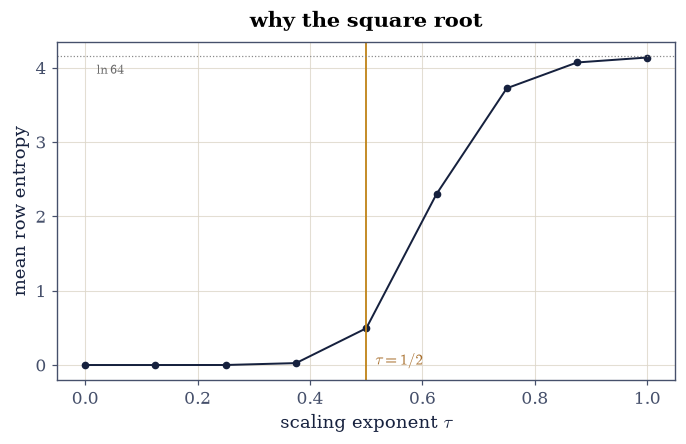

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.check(
    masked_exact and causal_rows < 1e-14,
    "the causal mask produces exact zeros, rows renormalized over the "
    "past",
    "exp(-inf) is an IEEE zero — 'cannot see the future' is an "
    "identity, and the gate is equality",
)
validate.check(
    abs(var_scaled - 1.0) < 0.05,
    "and 1/sqrt(d) holds the score variance at one",
    f"{var_scaled:.3f} over ten thousand dedicated-stream pairs — the "
    "calibration that keeps softmax on its usable slope at any width",
)

✓  the causal mask produces exact zeros, rows renormalized over the past   [exp(-inf) is an IEEE zero — 'cannot see the future' is an identity, and the gate is equality]
✓  and 1/sqrt(d) holds the score variance at one   [0.997 over ten thousand dedicated-stream pairs — the calibration that keeps softmax on its usable slope at any width]


True

## Exercise 3: Many heads are one matmul

**Part a)** Write the loop view `multi_head_loop(X)`: four heads of
width 8 (weights in the Setup-seeded lists `W_q_h`, `W_k_h`, `W_v_h`),
each running {eq}`eq-at-head`, outputs concatenated and mixed by
$W_O$.

**Write this one yourself** — then check it against the einsum block
view `multi_head_einsum(X)` of Part b.

**Part b)** Gate the block identity at $10^{-13}$: running the four
heads separately and concatenating equals the single batched einsum
`"hqd,hkd->hqk"` / `"hqk,hkd->hqd"` over a head axis followed by one
reshape and one matmul — multi-head attention is not four mechanisms
but one block-structured matrix product, which is why GPUs love it.

**Part c)** Draw the layer as a tensor diagram: $X$ fanning into
per-head $Q, K, V$ blocks, the head axis carried through the score
and value contractions, one output projection collecting the
concatenation.

In [9]:
# (solution hidden on the public site)


per-head loop + concat vs batched einsum + one matmul: 7.8e-16


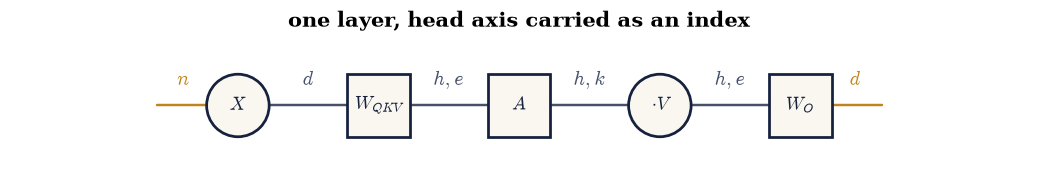

In [10]:
# (solution hidden on the public site)


### Validation 3

In [11]:
validate.below(
    gap_mh, 1e-13,
    "four heads concatenated equal one block-structured product",
    "the loop view and the head-axis einsum agree at rounding — "
    "multi-head is one matmul wearing a reshape",
)

✓  four heads concatenated equal one block-structured product   [the loop view and the head-axis einsum agree at rounding — multi-head is one matmul wearing a reshape [7.77156e-16 < 1e-13]]


True

## Exercise 4: The KV cache is an identity, and the cost is quadratic

**Part a)** Gate incremental decoding: process the sequence one token
at a time, appending each new key and value row to a growing cache
and computing only the newest query's attention row. The stacked
outputs equal full causal attention at $10^{-12}$ scaled (measured
near rounding) — the cache is
*exactly* the same mathematics reordered, which is the license every
inference engine runs on.

**Part b)** The ledger, counted and drawn: per layer, attention costs
$4n^2d$ FLOPs (scores + weighted sum) against the MLP block's
$16nd^2$; gate the crossover at exactly $n = 4d$ (arithmetic:
$4n^2d = 16nd^2 \iff n = 4d$) and draw both curves at $d = 64$ with
the crossover marked — past $n = 256$ the quadratic term owns the
budget, and every long-context architecture paper is an attempt to
move that line.

In [12]:
# (solution hidden on the public site)


incremental KV-cache decoding vs full recomputation: 8.9e-16
crossover: 4 n^2 d = 16 n d^2 at n = 4d = 256 (difference there: 0 flops — an identity)


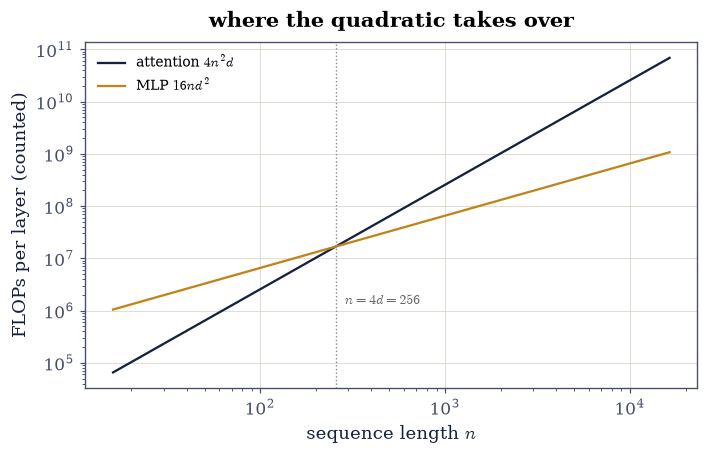

In [13]:
# (solution hidden on the public site)


### Validation 4

In [14]:
validate.below(
    gap_cache, 1e-12,
    "the KV cache reproduces full attention exactly-to-rounding",
    f"{gap_cache:.0e}: incremental decoding is the same mathematics "
    "reordered — an identity, and the inference industry's license",
)
validate.check(
    cross_gap == 0.0,
    "and the attention/MLP crossover sits at exactly n = 4d",
    "4 n^2 d = 16 n d^2 is n = 4d by arithmetic — counted, drawn, and "
    "the line every long-context paper is trying to move",
)

✓  the KV cache reproduces full attention exactly-to-rounding   [9e-16: incremental decoding is the same mathematics reordered — an identity, and the inference industry's license [8.88178e-16 < 1e-12]]
✓  and the attention/MLP crossover sits at exactly n = 4d   [4 n^2 d = 16 n d^2 is n = 4d by arithmetic — counted, drawn, and the line every long-context paper is trying to move]


True

## Exercise 5: Order: absent by default, relative by rotation

**Part a)** Gate permutation equivariance of the bare
(unmasked) head: for a random permutation $P$,
$\mathrm{Attn}(PX) = P\,\mathrm{Attn}(X)$ at $10^{-13}$ — attention
treats the sequence as a *set*. (The causal mask breaks this
trivially by fixing an order; the deep fix is positional encoding.)

**Part b)** Implement RoPE: rotate each consecutive 2-plane of $q$
and $k$ by $\theta_j m$ with per-plane frequencies
$\theta_j = 10000^{-2j/d}$, position $m$. Gate {eq}`eq-at-rope` over
100 random position pairs at $10^{-12}$ (measured
$2\times10^{-14}$): the score depends only on $m - n$ — *relative*
position from *absolute* rotations, because rotations compose by
adding angles.

**Part c)** Gate the breaking: with RoPE applied, the permutation
test of Part a fails by $O(1)$ (measured 1.27 — gated only as
exceeding 0.01, its size being the model's business). Order is now
information, which is the entire job of a positional encoding.

In [15]:
# (solution hidden on the public site)


permutation equivariance (bare attention): 4.4e-16
RoPE relative-position identity, 100 pairs: 2.5e-14
with RoPE the same test fails by 0.116 — order is now information


```{admonition} With your assistant
:class: tip
The head here is single-layer and frozen; real models stack and
train. Ask your assistant for `tiny_copy_transformer(seq_len, d)` —
one attention layer plus [§8.3](linear-layer-backpropagation.ipynb)'s
training loop, taught to copy the previous token on a synthetic
stream — then check it against the mathematics rather than a demo:
(i) after training, the attention matrix approximates the shifted
identity (mean weight on the correct previous token above 0.9);
(ii) with the causal mask removed the task becomes trivially
solvable and the learned pattern changes accordingly — compare the
two heatmaps; (iii) the trained model's KV-cache decode equals its
full forward pass at $10^{-12}$, because Exercise 4's identity is
architecture-independent. The check is yours.
```

### Validation 5

In [16]:
validate.below(
    gap_equiv, 1e-13,
    "bare attention is permutation-equivariant: sequences are sets",
    f"{gap_equiv:.0e} under a random shuffle — no positional signal "
    "exists in Eq. 1, which is a theorem about its symmetry",
)
validate.check(
    worst_rope < 1e-12,
    "RoPE scores depend only on the position difference (Eq. 2)",
    f"worst {worst_rope:.0e} over 100 random pairs — absolute "
    "rotations, relative scores, because angles add",
)
validate.check(
    break_size > 0.01,
    "and RoPE breaks the set symmetry, as a positional encoding must",
    f"the equivariance test now fails by {break_size:.2f} (O(1), size "
    "reported not gated) — order has become information",
)

✓  bare attention is permutation-equivariant: sequences are sets   [4e-16 under a random shuffle — no positional signal exists in Eq. 1, which is a theorem about its symmetry [4.44089e-16 < 1e-13]]
✓  RoPE scores depend only on the position difference (Eq. 2)   [worst 2e-14 over 100 random pairs — absolute rotations, relative scores, because angles add]
✓  and RoPE breaks the set symmetry, as a positional encoding must   [the equivariance test now fails by 0.12 (O(1), size reported not gated) — order has become information]


True

---
## Notebook summary

**One head is four products and a softmax, all gated.** Rows
stochastic at $10^{-16}$; the einsum spelling equal to the loops;
the heatmap showing repeated tokens finding each other through
nothing but shared embeddings and dot products. The causal mask's
zeros were *exact* ($e^{-\infty}$), and $1/\sqrt{d}$ held the score
variance at $0.997$ — with the entropy sweep showing what saturates
and what flattens on either side of the square root.

**Multi-head is one matmul; the cache is an identity; the cost is
arithmetic.** Four heads concatenated equalled the head-axis einsum
at $10^{-15}$; incremental KV-cache decoding equalled full causal
attention at rounding (gated at $10^{-12}$ scaled) — the inference
industry's license;
and the attention/MLP FLOP crossover sat at exactly $n = 4d$ by
identity, drawn at $d = 64$ where it lands on $n = 256$.

**Order is a choice.** Bare attention shuffled its outputs exactly
with its inputs ($10^{-16}$ — sequences are sets); RoPE's rotations
made scores depend only on position differences
($2\times10^{-14}$ over 100 pairs) and broke the shuffle symmetry by
a reported $1.27$ — position injected exactly where the mechanism
needed it and nowhere else.

**Methods introduced.** Head assembly from projections, row-wise
softmax gating, exact-zero causal masking, entropy-vs-temperature
sweeps, head-axis einsum for multi-head, KV-cache incremental
decoding, FLOP crossover ledgers, permutation-equivariance tests,
and RoPE with its relative-position identity.

## Outlook

- **Compression next.** [§8.6](low-rank-lora-quantization.ipynb)
  asks what happens to these weight matrices after training: LoRA is
  a rank decision (Chapter IV), quantization a rounding decision
  (Chapter V), and both are gated the course's way.
- **The quadratic wall.** Linear attention, sliding windows, and
  state-space models all bend Exercise 4's ink curve — every one of
  them a different factorization or sparsification of $A$, i.e.
  Chapters IV–VI applied to one matrix.
- **Attention as a kernel.** Rows of $A$ are
  [§6.5](../06-structure/kernels-gram-matrix.ipynb)'s similarity
  weights with a learned, asymmetric kernel — the connection that
  powers both theory (performers, random features) and intuition.
- **What remains is what breaks.** [§8.7](where-linear-algebra-stops.ipynb)
  closes the chapter with the boundary: the nonlinearities,
  normalizations and training dynamics where the linear story stops
  being the whole story — measured, as always.

```{bibliography}
:filter: docname in docnames
```

In [17]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>